# 08 — Simulador de escenarios operativos de reducción

**TFM: Predicción de emisiones de CO₂ de buques (THETIS-MRV)**

*Objetivo: responder al tercero de los tres objetivos declarados del TFM —«permitir simular
escenarios operativos de reducción de emisiones»—, con las tres restricciones que se derivan de la
interpretabilidad (notebook 07).*

Este notebook es la mitad analítica de la productivización; la API (`src/api.py`) es la mitad de
ingeniería, y **las dos comparten literalmente el mismo código**: todo lo que se ejecuta
aquí vive en `src/simulador.py`, y el notebook solo lo llama y lo interpreta. No hay ni una fórmula
duplicada entre el simulador que se enseña y el que se sirve.

**Lo que este notebook responde, en una frase**: si una naviera o un regulador puede mover las
palancas operativas de la flota, ¿cuánto CO₂ se ahorra, dónde conviene actuar, y con qué margen de
error se puede decir esa cifra.

> ### Nivel de información del simulador: operacional+tamaño
>
> En el **nivel operacional** (buque, tiempo y velocidad media) el mejor modelo es la mezcla 50/50
> de XGBoost y la red (R² 0,9215 en test). Con la **capacidad de carga** reconstruida en el notebook
> 03 a partir del propio registro público, XGBoost solo llega a **R² 0,9484** — por encima de esa
> mezcla y con un modelo en vez de dos.
>
> El simulador trabaja en ese nivel. Tres precisiones:
>
> 1. **No cambia el espacio de escenarios.** La capacidad de diseño de un buque no es una palanca de
>    gestión: entra como contexto que mejora la predicción, no como variable que el escenario mueva.
>    Siguen siendo dos grados de libertad, distancia y velocidad.
> 2. **La cifra de referencia no es la mezcla, sino XGBoost solo.** Promediarlo con una red
>    entrenada sobre menos información daría una predicción peor que la del mejor de los dos, así que
>    `simulador.py` **no ofrece** `'mezcla'` en este nivel. La red se conserva cargada como segunda
>    opinión para la banda de la sección 6.
> 3. **El nivel operacional sigue disponible** (`sim.cargar_modelos(..., nivel='operacional')`). La
>    sección 6 lo usa para medir cuánto se mueve el resultado, como comprobación de robustez.

## 0. Cobertura de la velocidad por año

Antes de simular nada conviene comprobar la cobertura de la velocidad por año, porque depende de un
cambio de esquema de la fuente:

| Año | % de filas sin velocidad (solo nombre antiguo) | % (con las dos convenciones) |
|---|---:|---:|
| 2018-2023 | entre 1,5% y 6,1% | entre 1,5% y 6,1% |
| **2024** | **100%** | **9,0%** |
| **2025** | **100%** | **13,6%** |

No es que EMSA dejara de publicar el dato: **le cambió el nombre a la columna**. Hasta el informe
de 2023 se llamaba `annual_average_fuel_consumption_per_distance_kg_n_mile`; desde el de 2024 se
llama `fuel_consumption_per_distance_kg_n_mile`. Buscando solo el nombre antiguo,
para los dos años más recientes la distancia saldría `NaN` entera **sin lanzar ninguna excepción**:
nada falla, todo se ejecuta, y el resultado está mal. Es el mismo tipo de cambio de esquema entre
ediciones que obliga a construir `ship_type_agrupado` en el notebook 03 — la taxonomía de tipos de
buque de EMSA cambia de la misma manera.

**Consecuencias de combinar las dos convenciones**, y son grandes:

- La cobertura de velocidad pasa del **68,2% al 94,0%**.
- El nivel operacional incluye **31.072 filas** (29% del dataset) y **297 Mt de CO₂** de 2024 y
  2025, que de otro modo quedarían fuera de esta parte del análisis.
- El simulador puede trabajar sobre **la flota más reciente publicada (2025)** en vez de tener que
  retroceder a 2023.
- Los dos modelos operacionales, con el mismo protocolo (`GroupKFold(3)` por buque, misma
  arquitectura, misma partición `es_train`), mejoran de forma clara:

| Modelo (nivel operacional) | R² CV (68,2%) | R² CV (94,0%) | R² test (68,2%) | R² test (94,0%) |
|---|---:|---:|---:|---:|
| XGBoost | 0,8932 | **0,9115** | 0,8977 | **0,9164** |
| Red 256-128-64 | 0,8937 | **0,9127** | 0,8980 | **0,9156** |
| **Media 50/50** | **0,9001** | **0,9179** | **0,9029** | **0,9215** |

El tratamiento está en `src/feature_engineering.py`: la función `_combinar_convenciones` acepta las
dos convenciones de nombre y **falla en voz alta** si alguna fila trajera valor en las dos a la vez,
en vez de suponer que son excluyentes. Los niveles principal y control no se tocan, porque no usan
distancia ni velocidad: el modelo de cabecera del TFM (R² 0,8266 en CV, 0,8380 la mezcla en test)
sigue siendo exactamente el mismo.

In [1]:
%matplotlib inline
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

sys.path.insert(0, '../src')
import simulador as sim

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 190)
plt.rcParams['figure.dpi'] = 110

df_ml = pd.read_parquet('../data/processed/mrv_features_operacional_tamano_ml.parquet')
df_raw = pd.read_parquet('../data/processed/mrv_features_operacional_tamano_raw.parquet')

# Mismo control de alineamiento que los notebooks 05 y 07: los índices de una tabla se usan sobre
# la otra, así que si dejaran de estar alineadas todo lo que sigue sería silenciosamente falso.
claves = ['reporting_year', 'ship_imo_number', sim.COL_TARGET, 'es_train']
assert len(df_ml) == len(df_raw)
assert all((df_ml[c].values == df_raw[c].values).all() for c in claves)

cobertura = (df_raw.groupby('reporting_year')['velocidad_nudos']
             .apply(lambda s: 100 * s.isna().mean()).round(1).rename('% sin velocidad'))
emisiones = (df_raw.groupby('reporting_year')[sim.COL_TARGET].sum() / 1e6).round(1).rename('Mt CO2')
print(pd.concat([cobertura, emisiones], axis=1).to_string())

                % sin velocidad  Mt CO2
reporting_year                         
2018                        6.1   145.0
2019                        3.3   146.7
2020                        3.4   129.6
2021                        4.3   126.7
2022                        3.5   137.2
2023                        2.0   128.4
2024                        9.0   146.9
2025                       13.6   150.1


In [2]:
modelos = sim.cargar_modelos('../models')          # por defecto, nivel operacional+tamaño
FAM = modelos['familia_principal']                 # la familia que produce la cifra publicada
FAMILIAS = modelos['familias']

test = df_ml[~df_ml['es_train']].reset_index(drop=True)
y_test = test[sim.COL_TARGET].values

print(f"Nivel de informacion: {modelos['nivel']} | familias disponibles: {FAMILIAS} | "
      f'referencia: {FAM}\n')
for familia in FAMILIAS:
    pred = sim.predecir(modelos, test, familia)
    print(f'  {familia:7s} R² {r2_score(y_test, pred):.4f} | MAE {mean_absolute_error(y_test, pred):,.0f} t'
          .replace(',', '.'))

# La red está entrenada sobre el nivel operacional, cuyas columnas son un subconjunto de las de
# este nivel: puede predecir sobre el mismo dataframe seleccionando las suyas. No entra en la cifra
# publicada (ver simulador.py), solo en la banda de la sección 6.

Nivel de informacion: operacional_tamano | familias disponibles: ('xgb', 'red') | referencia: xgb

  xgb     R² 0.9484 | MAE 1.489 t


  red     R² 0.9156 | MAE 1.936 t


## 1. Qué se puede simular, y por qué exactamente esto

El modelo del nivel operacional+tamaño ve **dos** variables movibles a corto plazo: las horas en el mar y
la velocidad media. La distancia recorrida no es una predictora, pero es la magnitud con sentido de
negocio, y las tres están unidas por una identidad física exacta:

$$\text{distancia (mn)} = \text{horas en el mar} \times \text{velocidad (nudos)}$$

Es decir, **solo hay dos grados de libertad**. Por eso un escenario aquí se define con dos
porcentajes —cuánto cambian las millas y cuánto cambia la velocidad— y **las horas se derivan**:

$$h' = h \cdot \frac{1 + \delta_d}{1 + \delta_v}$$

Fijar las tres a mano permitiría construir escenarios físicamente imposibles (recorrer las mismas
millas, en menos horas, a la misma velocidad) que el modelo aceptaría sin protestar, porque solo ve
dos de ellas. Derivar las horas cierra esa puerta. Es una restricción del simulador, no del modelo:
el modelo no sabe física, y por eso hay que ponérsela por fuera.

**Cómo se mide el ahorro: predicho contra predicho.** Nunca contra el dato observado. Comparar el
escenario con la emisión real mezclaría el efecto del escenario con el error del modelo en ese
buque, que en el peor caso del test son decenas de miles de toneladas (notebook 07). Al restar dos
predicciones del mismo modelo sobre la misma fila, el sesgo del modelo en ese buque se cancela y
queda el efecto del cambio. Es la diferencia entre un simulador y una tabla de errores.

**Las tres restricciones que se derivan del notebook 07**, y cómo las respeta este:

1. *Escenarios sobre distancia y horas, no sobre velocidad pura* — porque la elasticidad medida
   dentro de cada buque en el notebook 04 es 0,84 y no el 3 de la ley cúbica. La palanca de velocidad
   existe, pero se usa en la sección 4 para **medir ese límite**, no para acreditar ahorros.
2. *El efecto de una hora depende del tipo de buque* — de 3,02 t CO₂/h en carga general a 6,48 t/h
   en metaneros. Es lo que hace posible la sección 5.
3. *Bandas de incertidumbre, no cifras puntuales* — sección 6.

In [3]:
# Validación 1 del motor: el escenario nulo tiene que dar exactamente cero, no "casi" cero.
nulo = sim.simular(modelos, test, delta_distancia=0.0, delta_velocidad=0.0)
print('Ahorro del escenario sin cambios (debe ser 0,0 exacto):',
      nulo['por_familia'][FAM]['ahorro_t'])

# Validación 2: la identidad física se conserva fila a fila tras aplicar un escenario cualquiera.
antes = df_ml.head(2000)
despues, avisos = sim.aplicar_escenario(antes, delta_distancia=-0.10, delta_velocidad=-0.05)
con_velocidad = antes['velocidad_nudos'].notna().values
dist_antes = (antes['time_spent_at_sea_hours'] * antes['velocidad_nudos'])[con_velocidad]
dist_despues = (despues['time_spent_at_sea_hours'] * despues['velocidad_nudos'])[con_velocidad]
ratio = (dist_despues / dist_antes).dropna()
print(f'Ratio distancia después/antes con delta_distancia=-10%: '
      f'min {ratio.min():.6f} | max {ratio.max():.6f} (debe ser 0,9 en todas)')
print('Avisos del escenario:', {k: v for k, v in avisos.items() if k != 'factor_horas'})

Ahorro del escenario sin cambios (debe ser 0,0 exacto): 0.0
Ratio distancia después/antes con delta_distancia=-10%: min 0.900000 | max 0.900000 (debe ser 0,9 en todas)
Avisos del escenario: {'filas_afectadas': 2000, 'horas_recortadas_al_maximo': 0, 'filas_sin_velocidad_afectadas': 101, 'horas_totales_base': 6395985.800000001, 'horas_totales_escenario': 6059354.968421053}


## 2. La flota de 2025: el caso base

El escenario base es la flota completa del último año publicado. Antes de mover ninguna palanca
conviene ver cuánto se aleja la predicción agregada del dato observado: es una comprobación de
calibración que no aparece en ninguna métrica de los notebooks anteriores, porque el R² y el MAE miden
error **por buque**, no sesgo **agregado**. Y un simulador de política pública se lee en agregado.

In [4]:
es_2025 = (df_raw['reporting_year'] == 2025).values
ml_2025 = df_ml[es_2025].reset_index(drop=True)
raw_2025 = df_raw[es_2025].reset_index(drop=True)

base = {familia: sim.predecir(modelos, ml_2025, familia) for familia in FAMILIAS}

observado = raw_2025[sim.COL_TARGET].sum()
predicho = base[FAM].sum()
print(f'Flota 2025: {len(ml_2025):,} buques-año'.replace(',', '.'))
print(f'  CO2 observado : {observado / 1e6:8.2f} Mt')
print(f'  CO2 predicho  : {predicho / 1e6:8.2f} Mt  (sesgo agregado {100 * (predicho - observado) / observado:+.1f}%)')
print(f'  Horas de navegación totales: {raw_2025["time_spent_at_sea_hours"].sum():,.0f} h'.replace(',', '.'))
print(f'  Filas sin velocidad conocida: {ml_2025["velocidad_nudos"].isna().sum():,}'.replace(',', '.'))

Flota 2025: 16.939 buques-año
  CO2 observado :   150.10 Mt
  CO2 predicho  :   152.53 Mt  (sesgo agregado +1.6%)
  Horas de navegación totales: 36.576.291 h
  Filas sin velocidad conocida: 2.311


El sesgo agregado es de **+1,6%**: el modelo atribuye a la flota de 2025 unas 2,4 Mt de más sobre
150,1 Mt reales. No es ruido, es la firma de un modelo
entrenado con ocho años en los que la intensidad media era mayor. **Todos los ahorros que siguen se
reportan como diferencia entre dos predicciones**, así que ese sesgo se cancela; pero si alguien
quisiera leer el nivel absoluto de la línea base, tiene que saber que va un 1,6% alto.

Con el nivel operacional (sin tamaño) ese sesgo es del **+2,7%**. Reconstruir el tamaño del buque
no solo sube el R²: también **calibra mejor el agregado**, que es justo lo que el panel web le
enseña al usuario.

## 3. Palanca 1: menos millas a la misma velocidad

Es la palanca limpia. Recorrer un x% menos de millas manteniendo la velocidad significa navegar un
x% menos de horas, y las dos variables que el modelo ve se mueven de forma coherente. En términos
de negocio cubre todo lo que reduce millas sin cambiar la forma de navegar: optimización de rutas y
de red, consolidación de carga, eliminación de viajes en lastre, mejor planificación de escalas.

In [5]:
recortes = [-0.01, -0.02, -0.05, -0.075, -0.10, -0.15, -0.20]
rejilla = sim.rejilla_escenarios(modelos, ml_2025, recortes, [0.0])

tabla_millas = pd.DataFrame({
    'recorte de millas': [f'{100 * d:.1f}%' for d in rejilla['delta_distancia']],
    f'ahorro Mt ({FAM})': rejilla[f'ahorro_t_{FAM}'] / 1e6,
    'ahorro %': rejilla[f'ahorro_pct_{FAM}'],
    **{f'ahorro Mt ({f})': rejilla[f'ahorro_t_{f}'] / 1e6 for f in FAMILIAS if f != FAM},
})
tabla_millas.round(3)

,recorte de millas,ahorro Mt (xgb),ahorro %,ahorro Mt (red)
0,-1.0%,1.413,0.927,1.373
1,-2.0%,2.705,1.773,2.750
2,-5.0%,6.774,4.441,6.899
3,-7.5%,10.176,6.672,10.385
4,-10.0%,13.750,9.015,13.902
5,-15.0%,20.827,13.654,21.023
6,-20.0%,27.989,18.350,28.265


In [6]:
print(tabla_millas.round(3).to_string(index=False))

# Elasticidad implícita: ¿cuánto CO2 se mueve por cada punto de millas recortado?
elasticidad = rejilla[f'ahorro_pct_{FAM}'] / (-100 * rejilla['delta_distancia'])
print('\nElasticidad CO2 / millas por escenario:', np.round(elasticidad.values, 3))

recorte de millas  ahorro Mt (xgb)  ahorro %  ahorro Mt (red)
            -1.0%            1.413     0.927            1.373
            -2.0%            2.705     1.773            2.750
            -5.0%            6.774     4.441            6.899
            -7.5%           10.176     6.672           10.385
           -10.0%           13.750     9.015           13.902
           -15.0%           20.827    13.654           21.023
           -20.0%           27.989    18.350           28.265

Elasticidad CO2 / millas por escenario: [0.927 0.887 0.888 0.89  0.901 0.91  0.917]


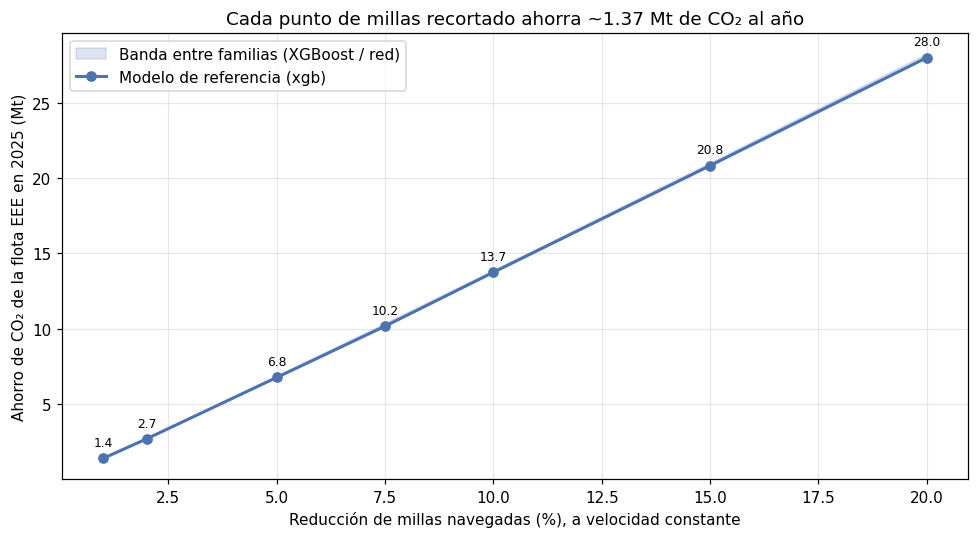

In [7]:
fig, eje = plt.subplots(figsize=(9, 5))

x = -100 * rejilla['delta_distancia']
eje.fill_between(x, rejilla['ahorro_t_xgb'] / 1e6, rejilla['ahorro_t_red'] / 1e6,
                 color='#4C72B0', alpha=0.18, label='Banda entre familias (XGBoost / red)')
eje.plot(x, rejilla[f'ahorro_t_{FAM}'] / 1e6, 'o-', color='#4C72B0', lw=2,
         label=f'Modelo de referencia ({FAM})')
for xi, yi in zip(x, rejilla[f'ahorro_t_{FAM}'] / 1e6):
    eje.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)

eje.set_xlabel('Reducción de millas navegadas (%), a velocidad constante')
eje.set_ylabel('Ahorro de CO₂ de la flota EEE en 2025 (Mt)')
eje.set_title(f'Cada punto de millas recortado ahorra ~{rejilla[f"ahorro_t_{FAM}"].iloc[-3] / 1e6 / 10:.2f} Mt de CO₂ al año')
eje.grid(alpha=0.3)
eje.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../reports/08_curva_millas.png', dpi=120)
plt.show()

**La respuesta es casi exactamente proporcional**: recortar un 10% de las millas de la flota ahorra
**13,75 Mt de CO₂**, un 9,0% de lo emitido. La elasticidad implícita ronda **0,90** y **sube muy
despacio** al crecer el recorte —de 0,887 con un 2% menos de millas a 0,917 con un 20% menos—, lo
que dice dos cosas: que en el rango realista el modelo no encuentra grandes no linealidades, y que
no hay ningún "punto dulce" que aproveche mejor un recorte pequeño; si acaso lo contrario, porque
cuanto mayor es el recorte menos pesa en el total la fracción de emisiones que no depende de las
millas.

El escenario del 1% se sale de esa progresión (0,927) y conviene no leerlo: un recorte tan pequeño
deja a la mayoría de los buques dentro de la misma región del árbol, así que el cociente entre dos
variaciones diminutas se vuelve inestable. Es el mismo fenómeno de la respuesta escalonada que se
ve en la ficha individual de la sección 7, aquí en su versión agregada.

Que sea 0,90 y no 1,00 tiene una explicación concreta: una parte de las
emisiones de un buque **no depende de las millas** (el tiempo en puerto, los auxiliares, la carga
hotelera de un crucero), y el modelo la ha aprendido de los datos. Un simulador que devolviera
proporcionalidad perfecta estaría, de hecho, siendo menos realista.

Para dar escala con una cifra del propio dataset: 13,75 Mt es casi lo que emitió en 2025 la flota
completa de graneleros del EEE (15,1 Mt), que son 4.774 buques-año — el tipo más numeroso de todos.

## 4. Palanca 2: *slow steaming*, y por qué su cifra es una cota inferior

Esta es la palanca que el notebook 07 marca con una advertencia, y aquí se ve por qué. Reducir la
velocidad manteniendo las millas significa **más horas en el mar** para la misma distancia, así que
las dos variables que el modelo ve se mueven en direcciones opuestas y el resultado no es evidente
a priori.

La física dice que el consumo por milla crece aproximadamente con el cuadrado de la velocidad (la
potencia va con el cubo, y el tiempo va con la inversa), así que la elasticidad del CO₂ respecto a
la velocidad a distancia constante debería rondar **2**. El notebook 04 mide dentro de cada buque
**0,84**. A continuación, lo que dice el modelo.

In [8]:
velocidades = [-0.20, -0.15, -0.10, -0.05, -0.02]
rejilla_v = sim.rejilla_escenarios(modelos, ml_2025, [0.0], velocidades)

tabla_velocidad = pd.DataFrame({
    'cambio de velocidad': [f'{100 * d:.0f}%' for d in rejilla_v['delta_velocidad']],
    'horas resultantes': [f'{100 * (1 / (1 + d) - 1):+.1f}%' for d in rejilla_v['delta_velocidad']],
    'ahorro Mt': rejilla_v[f'ahorro_t_{FAM}'] / 1e6,
    'ahorro %': rejilla_v[f'ahorro_pct_{FAM}'],
    'elasticidad implícita': rejilla_v[f'ahorro_pct_{FAM}'] / (-100 * rejilla_v['delta_velocidad']),
})
print(tabla_velocidad.round(3).to_string(index=False))
print('\nHoras recortadas al máximo físico del año en cada escenario:',
      rejilla_v['horas_recortadas'].tolist())

cambio de velocidad horas resultantes  ahorro Mt  ahorro %  elasticidad implícita
               -20%            +25.0%      4.357     2.856                  0.143
               -15%            +17.6%      3.456     2.266                  0.151
               -10%            +11.1%      2.369     1.553                  0.155
                -5%             +5.3%      1.110     0.728                  0.146
                -2%             +2.0%      0.454     0.298                  0.149

Horas recortadas al máximo físico del año en cada escenario: [98, 50, 25, 6, 1]


**El modelo sí acredita ahorro al *slow steaming*, pero muy por debajo de lo que la física
predice**: la elasticidad implícita es de **0,15**, frente al **0,84** medido dentro de cada buque
en el notebook 04 y al **~2** que se esperaría de la ley cúbica. Un 10% menos de velocidad da 2,37 Mt
(1,6%), pese a que las horas suben un 11,1%.

**Y con el tamaño dentro del modelo la elasticidad baja todavía más**: con el nivel operacional
sale 0,38, y aquí sale 0,15. No es un retroceso, es coherente con lo que encuentra el notebook 07: una parte de lo que la velocidad media parecía explicar era en realidad tamaño del
buque mal medido. En cuanto el tamaño entra de forma explícita, al coeficiente de la velocidad le
queda menos que explicar — y lo que queda está diluido por el defecto conocido de la variable.

La interpretación es la misma que justifica la restricción del notebook 07, y ahora está
cuantificada de cuatro formas coincidentes en dirección: `velocidad_nudos` es una **media anual**
que mezcla navegación con tiempo parado, así que mover esa media un 10% no equivale a que el buque
navegue un 10% más despacio.

**Un detalle de honestidad del cálculo**: al bajar la velocidad manteniendo las millas, las horas
suben, y en los escenarios más agresivos unas pocas filas se topan con el máximo físico del año
natural (98 filas con un −20% de velocidad, 1 con un −2%). El simulador las recorta y **lo dice en
los avisos**, porque un escenario que necesita recortar ya no es exactamente el escenario que se
pidió.

**Conclusión operativa, y es una conclusión con matiz, no un rechazo**: la cifra de *slow steaming*
que da este simulador debe leerse como una **cota inferior** del ahorro real, no como la mejor
estimación. Para acreditarlo bien haría falta separar horas de navegación de horas paradas, un dato
que el MRV público no publica. Es una limitación y una línea futura.

Es, además, un resultado del trabajo y no una cita: se ha medido con el mismo protocolo con el que
se mide todo lo demás, y las estimaciones (0,15 aquí, 0,38 sin el tamaño, 0,84 dentro de buque, ~2
teórica) dibujan un gradiente coherente — cuanta menos heterogeneidad entre buques se promedia, más
se acerca la elasticidad medida a la física.

Por eso **todo lo que sigue usa la palanca de millas**, que es la que el dato sostiene.

## 5. Dónde actuar: el mismo esfuerzo, el doble de resultado

Aquí es donde la interpretabilidad del notebook 07 se convierte en una recomendación. Si una hora de
metanero cuesta 6,48 t de CO₂ y una de carga general 3,02 t, entonces **no da igual dónde se
recorten las horas**. La pregunta bien planteada no es "¿cuánto ahorro con un 5% menos?", sino:
*con el mismo número total de horas de navegación evitadas en la flota, ¿cuánto cambia el resultado
según a quién se le quiten?*

Se comparan dos políticas que cuestan **exactamente las mismas horas de flota**:

- **Uniforme**: todos los buques recortan el mismo porcentaje.
- **Focalizada**: solo recortan los cuatro tipos de mayor intensidad por hora (metaneros, pasaje,
  ro-pax y portacontenedores), lo suficiente para evitar el mismo total de horas.

In [9]:
horas_flota = float(raw_2025['time_spent_at_sea_hours'].sum())
focalizado = sim.escenario_focalizado(modelos, ml_2025, raw_2025['ship_type_agrupado'],
                                      horas_a_evitar=0.05 * horas_flota,
                                      prediccion_base=base)

print(f'Horas de navegación evitadas en ambas políticas: {focalizado["horas_a_evitar"]:,.0f} h '
      f'(el 5% de la flota)'.replace(',', '.'))
print(f'Tipos objetivo de la política focalizada: {", ".join(focalizado["tipos_objetivo"])}')
print(f'  -> concentran {focalizado["horas_totales_objetivo"] / horas_flota:.1%} de las horas de la flota\n')
print(f'Recorte necesario | uniforme:   {focalizado["recorte_uniforme_pct"]:6.2f}% en todos los buques')
print(f'                  | focalizado: {focalizado["recorte_focalizado_pct"]:6.2f}% en los cuatro tipos\n')
print(f'Ahorro uniforme    : {focalizado["ahorro_uniforme_t"] / 1e6:6.2f} Mt CO2')
print(f'Ahorro focalizado  : {focalizado["ahorro_focalizado_t"] / 1e6:6.2f} Mt CO2')
print(f'Ventaja de focalizar: {focalizado["ventaja_focalizado_t"] / 1e6:+6.2f} Mt '
      f'({focalizado["ventaja_focalizado_pct"]:+.1f}%)')

Horas de navegación evitadas en ambas políticas: 1.828.815 h (el 5% de la flota)
Tipos objetivo de la política focalizada: LNG carrier, Passenger ship, Ro-pax ship, Container ship
  -> concentran 28.1% de las horas de la flota

Recorte necesario | uniforme:    -5.00% en todos los buques
                  | focalizado: -17.79% en los cuatro tipos

Ahorro uniforme    :   6.77 Mt CO2
Ahorro focalizado  :  13.50 Mt CO2
Ventaja de focalizar:  +6.73 Mt (+99.3%)


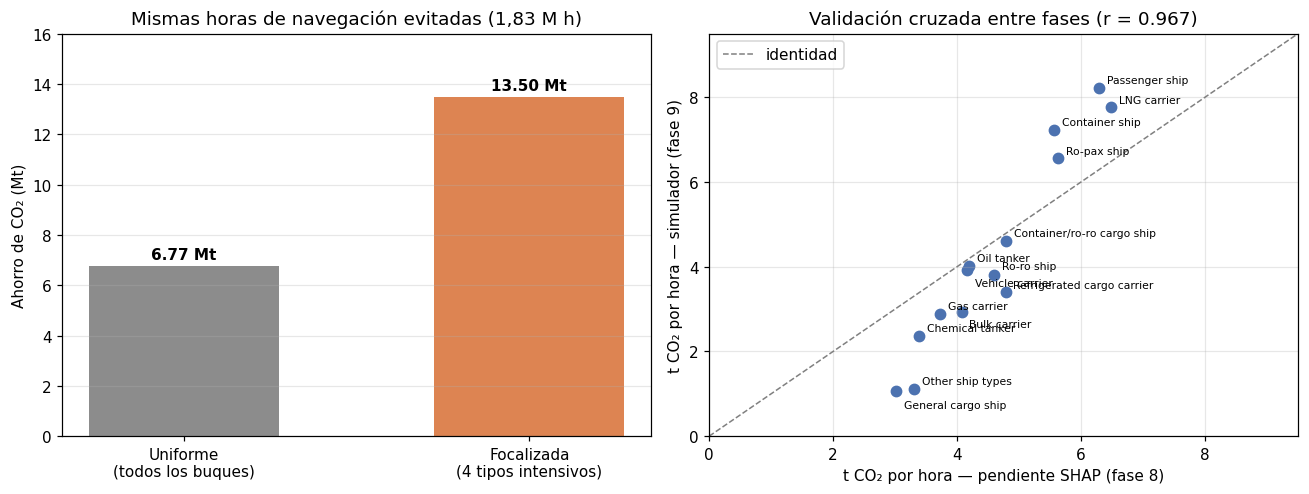

,n,co2_base_t,ahorro_t,ahorro_pct,t_por_hora,shap_t_por_hora
tipo,,,,,,
Container ship,2361,51442721.53,4866534.94,9.46,7.23,5.57
Oil tanker,1997,16733707.54,1610305.23,9.62,4.03,4.20
Bulk carrier,4774,15123201.16,1518229.65,10.04,2.93,4.08
Ro-pax ship,415,13695761.94,1081209.77,7.89,6.56,5.63
LNG carrier,406,10252904.85,927698.90,9.05,7.76,6.48
General cargo ship,2828,9411095.32,815197.11,8.66,1.07,3.02
Chemical tanker,1615,8885368.09,811054.45,9.13,2.37,3.39
Passenger ship,239,7426625.91,582398.34,7.84,8.22,6.29
Vehicle carrier,530,4436156.28,413946.19,9.33,3.92,4.16


In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6))

ejes[0].bar(['Uniforme\n(todos los buques)', 'Focalizada\n(4 tipos intensivos)'],
            [focalizado['ahorro_uniforme_t'] / 1e6, focalizado['ahorro_focalizado_t'] / 1e6],
            color=['#8C8C8C', '#DD8452'], width=0.55)
for i, valor in enumerate([focalizado['ahorro_uniforme_t'] / 1e6, focalizado['ahorro_focalizado_t'] / 1e6]):
    ejes[0].text(i, valor + 0.25, f'{valor:.2f} Mt', ha='center', fontweight='bold')
ejes[0].set_ylabel('Ahorro de CO₂ (Mt)')
ejes[0].set_title('Mismas horas de navegación evitadas (1,83 M h)')
ejes[0].set_ylim(0, 16)
ejes[0].grid(axis='y', alpha=0.3)

escenario_10 = sim.simular(modelos, ml_2025, delta_distancia=-0.10, prediccion_base=base)
por_tipo = sim.agregar_por_tipo(escenario_10, raw_2025['ship_type_agrupado'])
horas_tipo = raw_2025.groupby('ship_type_agrupado')['time_spent_at_sea_hours'].sum()
por_tipo['horas_evitadas'] = 0.10 * horas_tipo.reindex(por_tipo.index)
por_tipo['t_por_hora'] = por_tipo['ahorro_t'] / por_tipo['horas_evitadas']
pendientes_shap = pd.read_csv('../reports/07_pendiente_horas_por_tipo.csv').set_index('tipo')
por_tipo['shap_t_por_hora'] = pendientes_shap['t_CO2_por_hora_navegada']

comparable = por_tipo.dropna(subset=['shap_t_por_hora'])
ejes[1].scatter(comparable['shap_t_por_hora'], comparable['t_por_hora'], s=45, color='#4C72B0')
# Desplazamientos manuales solo donde dos tipos caen casi encima (carga general y "other").
desplazamiento = {'General cargo ship': (5, -11), 'Ro-ro ship': (5, 4),
                  'Vehicle carrier': (5, -10), 'Bulk carrier': (5, -10)}
for nombre, fila in comparable.iterrows():
    ejes[1].annotate(nombre, (fila['shap_t_por_hora'], fila['t_por_hora']),
                     textcoords='offset points', xytext=desplazamiento.get(nombre, (5, 3)),
                     fontsize=7)
limites = [0, 9.5]
ejes[1].plot(limites, limites, '--', color='grey', lw=1, label='identidad')
ejes[1].set_xlim(*limites); ejes[1].set_ylim(*limites)
ejes[1].set_xlabel('t CO₂ por hora — pendiente SHAP (fase 8)')
ejes[1].set_ylabel('t CO₂ por hora — simulador (fase 9)')
ejes[1].set_title(f'Validación cruzada entre fases (r = '
                  f'{comparable[["t_por_hora", "shap_t_por_hora"]].corr().iloc[0, 1]:.3f})')
ejes[1].grid(alpha=0.3); ejes[1].legend()

plt.tight_layout()
plt.savefig('../reports/08_focalizado_y_validacion.png', dpi=120)
plt.show()

por_tipo[['n', 'co2_base_t', 'ahorro_t', 'ahorro_pct', 't_por_hora', 'shap_t_por_hora']].round(2)

In [11]:
por_tipo.to_csv('../reports/08_ahorro_por_tipo.csv')
print(por_tipo[['n', 'ahorro_t', 'ahorro_pct', 't_por_hora', 'shap_t_por_hora']].round(2).to_string())

                               n    ahorro_t  ahorro_pct  t_por_hora  shap_t_por_hora
tipo                                                                                 
Container ship              2361  4866534.94        9.46        7.23             5.57
Oil tanker                  1997  1610305.23        9.62        4.03             4.20
Bulk carrier                4774  1518229.65       10.04        2.93             4.08
Ro-pax ship                  415  1081209.77        7.89        6.56             5.63
LNG carrier                  406   927698.90        9.05        7.76             6.48
General cargo ship          2828   815197.11        8.66        1.07             3.02
Chemical tanker             1615   811054.45        9.13        2.37             3.39
Passenger ship               239   582398.34        7.84        8.22             6.29
Vehicle carrier              530   413946.19        9.33        3.92             4.16
Ro-ro ship                   237   408476.28        7.

**Focalizar duplica el resultado**: las mismas 1,83 millones de horas de navegación evitadas ahorran
**6,77 Mt** repartidas por igual y **13,50 Mt** concentradas en los cuatro tipos intensivos — un
**+99,3%**, sin gastar una hora más. Es la recomendación accionable de todo el trabajo.

*(Con el nivel operacional la ventaja es del +101,8%; en ambos niveles, focalizar **duplica** el
ahorro.)*

El precio de esa política es evidente y hay que decirlo: los cuatro tipos objetivo concentran solo
el 28,1% de las horas de la flota, así que evitar ahí el mismo total exige recortarles un 17,8% de
su actividad, frente al 5% repartido. Es más ahorro, pero también más concentrado en menos actores.

**Y el gráfico de la derecha es la validación cruzada más importante del notebook.** Las toneladas
por hora evitada que produce el simulador —una magnitud calculada moviendo variables y prediciendo
de nuevo— coinciden con las pendientes SHAP que el notebook 07 estima por un camino completamente
distinto, con una correlación de **0,967** entre los **catorce** tipos de buque comparables (el
*combination carrier* no tiene pendiente SHAP publicada, y son cuatro filas de test). Dos métodos
independientes, el mismo resultado: es lo más cerca que se puede estar de comprobar que el simulador
no está inventándose nada.

Las discrepancias también son informativas y van en la misma dirección en los dos extremos: el
simulador da más toneladas por hora que SHAP en los tipos intensivos (portacontenedores 7,23 frente
a 5,57; pasaje 8,22 frente a 6,29) y menos en los ligeros (carga general 1,07 frente a 3,02). La
razón es que la pendiente SHAP es una media sobre buques muy distintos dentro del tipo, mientras
que el recorte porcentual del simulador quita más horas justamente a los buques que más navegan,
que son también los que más emiten por hora. **Es un matiz importante**: la interpretabilidad y el simulador
dan dos cifras distintas para la misma idea, y sin esta explicación se leerían como una
contradicción.

## 6. Cuánta confianza merece la cifra

Un simulador que devuelve "13,75 Mt" sin más está diciendo más de lo que sabe. Hay tres fuentes de
incertidumbre distintas y conviene separarlas, porque no se combaten igual:

1. **Qué modelo se eligió** — la banda entre XGBoost y la red. Es la que un lector se pregunta
   después de haber visto dos familias comparadas durante todo el trabajo.
2. **Qué flota se observó** — remuestreo bootstrap **de buques** (no de filas: los años del mismo
   buque no son observaciones independientes, igual que en la partición del notebook 03).
3. **Con qué buques falla más el modelo** — el error relativo por tamaño, que el notebook 04 mide y
   que aquí hay que arrastrar hasta la salida.

In [12]:
banda_min, banda_central, banda_max = sim.banda_familias(escenario_10)
ahorro_por_fila = (escenario_10['predicciones'][FAM]['base']
                   - escenario_10['predicciones'][FAM]['escenario'])
inferior, superior = sim.bootstrap_flota(ahorro_por_fila, raw_2025['ship_imo_number'])

print('Escenario: 10% menos de millas en la flota de 2025\n')
print(f'  Estimación central ({FAM:<16s}): {banda_central / 1e6:6.2f} Mt')
print(f'  Banda por elección de modelo      : [{banda_min / 1e6:.2f} , {banda_max / 1e6:.2f}] Mt '
      f'(±{100 * (banda_max - banda_min) / 2 / banda_central:.1f}%)')
print(f'  Intervalo bootstrap 95% (buques)  : [{inferior / 1e6:.2f} , {superior / 1e6:.2f}] Mt '
      f'(±{100 * (superior - inferior) / 2 / banda_central:.1f}%)')

Escenario: 10% menos de millas en la flota de 2025

  Estimación central (xgb             ):  13.75 Mt
  Banda por elección de modelo      : [13.75 , 13.90] Mt (±0.6%)
  Intervalo bootstrap 95% (buques)  : [13.38 , 14.13] Mt (±2.7%)


### 6.1. ¿Cuánto se mueve la cifra al cambiar de modelo y de nivel de información?

Es la comprobación que da sentido a conservar el nivel operacional. La pregunta que se responde
aquí no es la habitual ("¿y si hubiera elegido la otra familia de modelos?") sino una más exigente:
**¿y si además se trabajara sin reconstruir el tamaño del buque?**

In [13]:
modelos_v3 = sim.cargar_modelos('../models', nivel='operacional')
ml_2025_v3 = ml_2025[[c for c in ml_2025.columns]]        # el nivel 3 usa un subconjunto de columnas

escenario_10_v3 = sim.simular(modelos_v3, ml_2025_v3, delta_distancia=-0.10)
ahorro_v3 = escenario_10_v3['por_familia'][modelos_v3['familia_principal']]['ahorro_t']
base_v3 = escenario_10_v3['por_familia'][modelos_v3['familia_principal']]['co2_base_t']

comparacion_niveles = pd.DataFrame([
    {'nivel': '3. operacional (publicado en agosto)',
     'modelo': modelos_v3['familia_principal'], 'R2_test': 0.9215,
     'co2_base_Mt': base_v3 / 1e6, 'ahorro_Mt': ahorro_v3 / 1e6},
    {'nivel': '4. operacional + tamano (actual)',
     'modelo': FAM, 'R2_test': modelos['metricas_xgb_test'].get('R2', float('nan')),
     'co2_base_Mt': escenario_10['por_familia'][FAM]['co2_base_t'] / 1e6,
     'ahorro_Mt': escenario_10['por_familia'][FAM]['ahorro_t'] / 1e6},
])
comparacion_niveles['sesgo_base_pct'] = 100 * (comparacion_niveles['co2_base_Mt'] * 1e6 - observado) / observado
comparacion_niveles.to_csv('../reports/08_comparacion_niveles.csv', index=False)
print(comparacion_niveles.round(3).to_string(index=False))

cambio = 100 * (escenario_10['por_familia'][FAM]['ahorro_t'] - ahorro_v3) / ahorro_v3
print(f'\nCambio de la cifra publicada al migrar de nivel: {cambio:+.2f}%')

                               nivel modelo  R2_test  co2_base_Mt  ahorro_Mt  sesgo_base_pct
3. operacional (publicado en agosto) mezcla    0.922      154.144     13.689           2.695
    4. operacional + tamano (actual)    xgb    0.948      152.527     13.750           1.618

Cambio de la cifra publicada al migrar de nivel: +0.45%


**La cifra apenas se mueve, y eso es un resultado.** Un modelo con 0,027 más de R² y una variable
nueva que resultó explicar el 18,5% de las emisiones (notebook 07) desplaza el ahorro estimado un
**+0,45%**: de 13,689 a 13,750 Mt. Dicho de otro modo: **la recomendación de política no depende de
la limitación de datos que el trabajo levanta**.

Donde sí se nota la mejora es en el **sesgo agregado de la línea base**, que baja del **+2,7% al
+1,6%** sobre la flota observada de 2025. Ese sesgo no afecta a los ahorros —que son diferencias
entre dos predicciones del mismo modelo— pero sí a la credibilidad del nivel absoluto que el panel
web muestra al usuario.

In [14]:
fiabilidad = sim.fiabilidad_por_tamano(y_test, sim.predecir(modelos, test, FAM))
print(fiabilidad.round(1).to_string())

            n  co2_mediano_t  error_relativo_mediano_pct
quintil                                                 
1        4221         1100.7                        19.5
2        4221         3300.1                        11.9
3        4221         5741.3                        10.9
4        4221        10155.6                        10.4
5        4221        26138.0                         9.7


Las dos bandas son **estrechas**, y conviene decir con precisión qué mide cada una:

- **La elección de modelo mueve la cifra un ±0,6%** (13,75 a 13,90 Mt). A diferencia del nivel
  operacional, donde se comparan dos modelos entrenados sobre **la misma** información y la cifra
  publicada cae dentro, aquí la referencia (XGBoost del nivel operacional+tamaño) **es el
  extremo inferior**, y el otro extremo lo pone una red entrenada sobre menos información. Es decir,
  esta banda ya no responde a *«¿y si hubiera elegido la otra familia?»* sino a la pregunta más
  exigente de la sección 6.1: *«¿y si además se trabajara sin reconstruir el tamaño?»*. Es una
  banda asimétrica **a propósito**.
- **El muestreo de buques mueve la cifra un ±2,7%** (13,38 a 14,13 Mt). Con casi 17.000 buques-año
  el agregado está bien determinado; la banda es algo más ancha que la del nivel operacional (±2,2%) porque el
  modelo nuevo discrimina más entre buques y, al remuestrearlos, el agregado varía algo más.

**El aviso que hay que arrastrar es el tercero, y es el que no se ve en el agregado**: el error
relativo mediano del modelo es del **19,5%** en el quintil de buques que menos emiten, frente al
**9,7%-11,9%** de los otros cuatro. Es una mejora grande sobre el nivel operacional —donde ese quintil
va al 26,1%— pero el gradiente sigue ahí, y la consecuencia práctica no cambia: **la cifra agregada
de flota es fiable, la cifra individual de un buque pequeño no lo es**, y la API debe
devolverla con esa advertencia en la respuesta, no en la documentación.

## 7. Del agregado al buque: la ficha individual

Es la unidad que consume la API y el caso demostrativo. El buque se elige con un
**criterio objetivo de cuatro condiciones**, no a mano, y las cuatro están implementadas en la celda
siguiente para que cualquiera pueda reproducir la elección:

1. **velocidad conocida** — sin ella no hay palanca que mover;
2. **error del modelo por debajo del 10%** — para que la demostración no se apoye en un buque que el
   modelo predice mal;
3. **fuera del entrenamiento** (`es_train == False`) — para que la predicción no pueda atribuirse a
   memorización, que es la objeción evidente;
4. **respuesta monótona en la escalera de escenarios** — recortar más millas tiene que ahorrar más.

La cuarta condición no es un capricho: en este nivel de información **el 3,6% de los buques de 2025
(609 de 16.939) responde con un ahorro negativo** al recortar un 10% de las millas, por el efecto
escalonado de los modelos de árboles. Sobre el agregado eso pesa un 2% del ahorro total y se
promedia; sobre un buque suelto arruinaría la demostración. Elegir un caso sin comprobarlo sería
elegir a ciegas.

In [15]:
prediccion_2025 = base[FAM]
candidatos = raw_2025.assign(
    predicho=prediccion_2025,
    error_relativo=np.abs(prediccion_2025 - raw_2025[sim.COL_TARGET]) / raw_2025[sim.COL_TARGET])

# Las cuatro condiciones del criterio, en el mismo orden en que se declaran arriba. Las dos
# ultimas son las que impiden elegir a ciegas: sin `es_train == False` la prediccion podria
# atribuirse a memorizacion, y sin la comprobacion de monotonia podria tocar uno de los 609 buques
# (3,6% de la flota de 2025) cuya respuesta escalonada da un ahorro negativo al recortar millas.
candidatos = candidatos[candidatos['velocidad_nudos'].notna()
                        & (candidatos['error_relativo'] < 0.10)
                        & (~candidatos['es_train'])]

ESCALERA = [(0.0, 0.0), (-0.05, 0.0), (-0.10, 0.0), (-0.20, 0.0)]


def responde_monotonamente(imo):
    ahorros = sim.simular_buque(modelos, ml_2025, raw_2025, imo=imo, anio=2025,
                                escenarios=ESCALERA)['ahorro_t'].tolist()
    return all(posterior > anterior for anterior, posterior in zip(ahorros, ahorros[1:]))


elegido = None
for _, fila in candidatos.nlargest(20, sim.COL_TARGET).iterrows():
    if responde_monotonamente(fila['ship_imo_number']):
        elegido = fila
        break
if elegido is None:
    raise RuntimeError('ningun candidato de los 20 mayores cumple las cuatro condiciones')

print(f"{elegido['ship_name']} ({elegido['ship_type_agrupado']}, {elegido['reporting_year']})")
print(f"  IMO {elegido['ship_imo_number']}")
print(f"  CO2 observado : {elegido[sim.COL_TARGET]:,.0f} t".replace(',', '.'))
print(f"  CO2 predicho  : {elegido['predicho']:,.0f} t  "
      f"(error {100 * elegido['error_relativo']:.1f}%)".replace(',', '.'))
print(f"  Operación 2025: {elegido['time_spent_at_sea_hours']:,.0f} h en el mar | "
      f"{elegido['velocidad_nudos']:.1f} nudos | {elegido['distancia_nm']:,.0f} mn".replace(',', '.'))

CRUISE BARCELONA (Ro-pax ship, 2025)


  IMO 9351488
  CO2 observado : 100.073 t
  CO2 predicho  : 99.584 t  (error 0.5%)
  Operación 2025: 5.307 h en el mar | 21.2 nudos | 112.471 mn


In [16]:
escenarios_buque = [(0.0, 0.0), (-0.05, 0.0), (-0.10, 0.0), (-0.20, 0.0),
                    (0.0, -0.10), (-0.10, -0.10)]
ficha = sim.simular_buque(modelos, ml_2025, raw_2025,
                          imo=elegido['ship_imo_number'], anio=2025,
                          escenarios=escenarios_buque)

print(f"{ficha.attrs['buque']} — {ficha.attrs['tipo']}")
print(f"CO2 observado {ficha.attrs['co2_observado_t']:,.0f} t | "
      f"predicho {ficha.attrs['co2_base_predicho_t']:,.0f} t\n".replace(',', '.'))
print(ficha.round(1).to_string(index=False))

CRUISE BARCELONA — Ro-pax ship
CO2 observado 100.073 t | predicho 99.584 t

 delta_distancia_pct  delta_velocidad_pct  horas  velocidad_nudos  co2_predicho_t  ahorro_t  ahorro_pct
                 0.0                  0.0 5307.3             21.2         99584.0       0.0         0.0
                -5.0                  0.0 5042.0             21.2         92138.2    7445.7         7.5
               -10.0                  0.0 4776.6             21.2         82916.1   16667.9        16.7
               -20.0                  0.0 4245.9             21.2         70823.8   28760.2        28.9
                 0.0                -10.0 5897.0             19.1        100935.2   -1351.2        -1.4
               -10.0                -10.0 5307.3             19.1         90930.9    8653.1         8.7


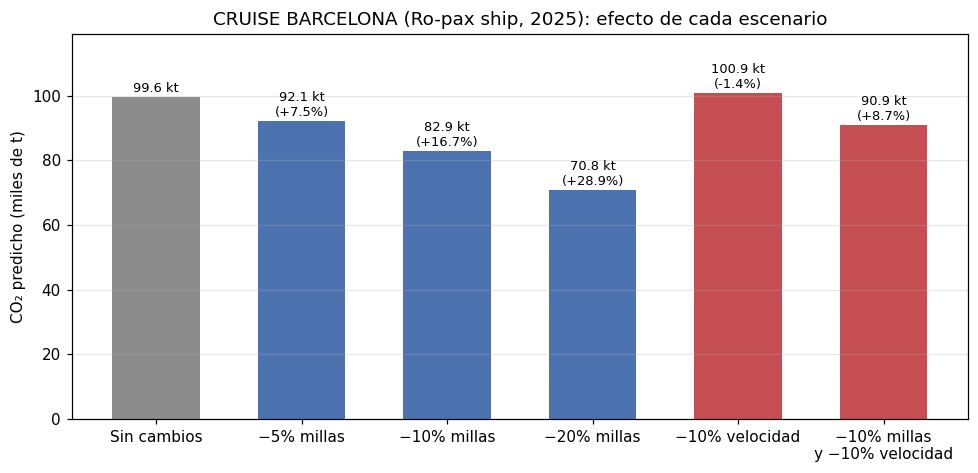

In [17]:
fig, eje = plt.subplots(figsize=(9, 4.4))

etiquetas = ['Sin cambios', '−5% millas', '−10% millas', '−20% millas',
             '−10% velocidad', '−10% millas\ny −10% velocidad']
colores = ['#8C8C8C'] + ['#4C72B0'] * 3 + ['#C44E52'] * 2
eje.bar(etiquetas, ficha['co2_predicho_t'] / 1000, color=colores, width=0.6)
for i, (valor, ahorro) in enumerate(zip(ficha['co2_predicho_t'] / 1000, ficha['ahorro_pct'])):
    texto = f'{valor:.1f} kt' + (f'\n({ahorro:+.1f}%)' if i else '')
    eje.text(i, valor + 1.5, texto, ha='center', fontsize=8.5)

eje.set_ylabel('CO₂ predicho (miles de t)')
eje.set_title(f'{ficha.attrs["buque"]} ({ficha.attrs["tipo"]}, 2025): efecto de cada escenario')
eje.set_ylim(0, ficha['co2_predicho_t'].max() / 1000 * 1.18)
eje.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/08_ficha_buque.png', dpi=120)
plt.show()

ficha.to_csv('../reports/08_ficha_buque.csv', index=False)

La ficha individual deja ver tres cosas que el agregado esconde, y las tres hay que decirlas:

**El caso sale redondo, y no por casualidad.** El CRUISE BARCELONA se predice con un **0,5% de
error** (99.584 t predichas frente a 100.073 observadas) siendo un buque que el modelo **no vio
nunca entrenando**. Y este mismo buque es **el mayor emisor mal predicho** del diagnóstico del notebook 07 —con el
modelo del nivel principal se queda 50.278 t corto, prueba de que al modelo le falta el tamaño del
buque—. Con el tamaño reconstruido, el error cae a 489 t: el caso demostrativo muestra además que
esa limitación está levantada.

**La respuesta de un buque concreto no es proporcional, es escalonada.** Aquí sí crece de forma
ordenada —es una de las cuatro condiciones con las que se ha elegido— pero no es lineal: un −5% de
millas ahorra un 7,5%, un −10% un 16,7% y un −20% un 28,9%. Es lo que hace un modelo de árboles, que
parte el espacio en regiones y devuelve el mismo valor dentro de cada una. En el agregado de 17.000
buques esos escalones se promedian y la curva de la sección 3 sale suave; en un buque suelto se ven.
La lectura correcta de una ficha individual es por lo tanto **el orden de magnitud del ahorro y su
signo**, no el decimal.

**Y en un buque concreto el *slow steaming* puede salir negativo.** Bajarle un 10% la velocidad
manteniendo las millas le sube el CO₂ predicho un 1,4%: las horas pasan de 5.307 a 5.897 y, para
este modelo, las horas pesan más que el ahorro por milla que la física esperaría. No es un fallo del
simulador, es exactamente el límite que la sección 4 acaba de cuantificar sobre el agregado, visto
en un solo buque. Combinar las dos palancas —un 10% menos de millas *y* un 10% menos de velocidad—
sí ahorra (8,7%), pero menos que recortar millas a secas.

Es también el motivo de que la API devuelva la banda entre familias y el aviso de
fiabilidad junto a cada predicción individual: sobre un solo buque, el error del modelo ya no se
compensa con nadie.

## 8. Conclusiones

**Las tres cifras principales:**

1. **Un 10% menos de millas en la flota del EEE ahorraría 13,75 Mt de CO₂ al año** (banda por
   elección de modelo 13,75-13,90; bootstrap 95% 13,38-14,13). La respuesta es casi proporcional
   —elasticidad 0,90— y esa pequeña desviación de la proporcionalidad perfecta es informativa: hay
   una fracción de las emisiones que no depende de las millas y el modelo la ha aprendido.
2. **Focalizar duplica el resultado a igualdad de esfuerzo**: las mismas 1,83 M de horas de
   navegación evitadas rinden 6,77 Mt repartidas uniformemente y 13,50 Mt concentradas en
   metaneros, pasaje, ro-pax y portacontenedores (**+99,3%**). Es la traducción directa del resultado
   del notebook 07 sobre las toneladas por hora de cada tipo.
3. **El *slow steaming* sale acreditado con una elasticidad de 0,15**, frente al 0,38 que salía sin
   el tamaño dentro del modelo, el 0,84 medido dentro de cada buque en el notebook 04 y el ~2 de la ley
   cúbica. La cifra del simulador es una **cota inferior**, y la razón está identificada: la
   velocidad media anual mezcla navegación con tiempo parado.

**El resultado de robustez, que es el que más tranquilidad da** (sección 6.1): migrar del nivel
operacional al operacional+tamaño —0,027 más de R² y una variable nueva que explica el 18,5% de las
emisiones— mueve la cifra de cabecera un **+0,45%**. La recomendación de política no depende de la
limitación de datos que el trabajo levanta.

**Lo que da credibilidad al simulador**: sus
toneladas por hora evitada coinciden con las pendientes SHAP del notebook 07 con una correlación de
**0,967** entre los catorce tipos de buque comparables, habiéndose calculado por caminos
completamente distintos —una moviendo variables y volviendo a predecir, la otra descomponiendo
predicciones—. Es una validación cruzada entre notebooks, no una comprobación interna.

**Las tres limitaciones, ya cuantificadas:**

- El nivel absoluto de la línea base va un **+1,6%** alto sobre la flota de 2025 (+2,7% sin
  reconstruir el tamaño). No afecta a los ahorros, que son diferencias de predicciones, pero sí a
  cualquier lectura del nivel.
- El error relativo mediano es del **19,5%** en el quintil de buques que menos emiten frente al
  9,7%-11,9% del resto: **el agregado es fiable, el buque pequeño individual no**. Y hay un precio
  del nivel con tamaño: los buques con respuesta negativa al recorte de millas pasan del 2,0% al
  **3,6%** de la flota. Se gana precisión agregada y se pierde algo de suavidad
  individual.
- La palanca de velocidad está infravalorada por la naturaleza del dato publicado. Separar horas de
  navegación de horas paradas es hoy **la línea de enriquecimiento más rentable que queda**, una vez
  que el tamaño del buque —la que señala el notebook 07— está resuelto.

**Lo que usa la API**:

- `src/simulador.py` es el motor completo y no depende del notebook. La API es una envoltura
  `FastAPI` sobre `simular_buque` (una fila, unos deltas, una respuesta) y `simular` (una flota).
- La respuesta incluye la banda entre familias y el aviso de fiabilidad por tamaño:
  `banda_familias` y `fiabilidad_por_tamano` ya viven en el módulo precisamente para eso.
- El coste no es un problema: XGBoost tarda decenas de milisegundos sobre las 21.105 filas de test,
  así que un escenario de flota completa es cuestión de décimas de segundo.